# Cuộc thi dự báo: Yelp + thời tiết ERA5

## Goal — Chúng ta muốn biết điều gì?

Hãy tưởng tượng có nhiều bạn cùng đoán **ngày mai sẽ có bao nhiêu check-in**.
Có bạn chỉ nhìn tuần trước. Có bạn học từ nhiều ngày. Có bạn được xem thêm thời tiết.
Notebook này tổ chức một cuộc thi công bằng giữa các cách đoán ấy.

**Hai câu hỏi:**
1. Cách nào đoán số check-in kỳ vọng tốt hơn trên những ngày chưa dùng để chọn mô hình?
2. Biết thêm thời tiết đã xảy ra có giúp mô hình không?

Mỗi dòng là **một thành phố, một ngành hàng, một ngày**. Chúng ta cộng check-in của
một danh sách doanh nghiệp cố định. Check-in là sự kiện ghi nhận trên Yelp, chưa phải
số khách, doanh thu hay mức thành công của một cửa hàng.

**Có hai cuộc thi khác nhau:**
- `no_weather`: dùng lịch và check-in các ngày trước. Đây là backtest dự báo ngày kế tiếp,
  với giả định dữ liệu ngày hôm qua đã được nhận đầy đủ.
- `observed_weather`: được xem ERA5 của chính ngày cần đoán. Đây là **thí nghiệm hồi cứu**,
  giống như được xem thêm một gợi ý sau khi ngày đó đã diễn ra. Điểm này chưa chứng minh
  khả năng dự báo thời tiết/hoạt động trong tương lai.

Notebook không tải lại hai dataset. Các kết quả chỉ xuất hiện sau khi chạy code thật.

## Setup — Chuẩn bị hai cuốn sổ và dụng cụ

**Cuốn sổ 1: Yelp.** Chạy notebook [01](01_yelp_dataset_exploration.ipynb) để có
`business.jsonl` và `checkin.jsonl` dưới `data/raw/yelp_exploration/`.

**Cuốn sổ 2: ERA5.** Chạy notebook [02](02_yelp_weather_dataset_exploration.ipynb)
để có mapping và các file thời tiết **theo giờ** dưới `data/processed/yelp_weather/`.
Không ghép thẳng summary UTC với ngày địa phương.

Từ thư mục gốc của repo:

```sh
uv sync --frozen --group notebooks
uv run --frozen --group notebooks jupyter lab --notebook-dir=.
```

Chọn `.venv/bin/python` làm kernel, rồi dùng **Restart Kernel and Run All**.
Các bước nặng nằm trong hai module Python để notebook có thể đọc như một bài học.
Lần chạy mặc định đọc lại file local, không cần database hay API key.

In [1]:
import os
import tempfile
from pathlib import Path

# Một CPU thread giúp phép đo ổn định và tránh chiếm hết máy.
os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "sitesense-mpl-cache"))

'/var/folders/xy/r328p6dn5j18rldgdk30ll040000gn/T/sitesense-mpl-cache'

In [2]:
import hashlib
import json
import platform
from dataclasses import asdict
from datetime import UTC, datetime
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from sitesense.forecast_data import CityScope, prepare_city_panel
from sitesense.forecast_models import (
    ValidationFold,
    build_features,
    candidate_configs,
    compare_validation,
    count_metrics,
    evaluate_holdout,
    experiment_versions,
    paired_weather_uplift,
)

ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").exists() and (path / "src/sitesense").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Hãy mở notebook từ thư mục sitesense hoặc notebooks/.")

plt.rcParams.update(
    {
        "figure.figsize": (11, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)
pd.set_option("display.max_columns", 15)
print("Python:", platform.python_version())
display(pd.DataFrame([experiment_versions()]))

Python: 3.13.5


,numpy,pandas,scikit-learn,catboost,threadpoolctl
0,2.5.3,3.0.6,1.9.1,1.2.10,3.7.0


### Chọn cuộc thi trước khi xem điểm

Mặc định: Restaurants tại Philadelphia, Tampa và Nashville; dữ liệu 2013–2021.
Một doanh nghiệp được vào danh sách nếu có ít nhất 20 check-in trong 2013–2016.
Chúng ta **không nhìn check-in năm test để quyết định ai được tham gia**.

Timestamp Yelp chưa có múi giờ. `local` nghĩa là giả sử giờ ghi trong Yelp là giờ địa phương;
`utc` nghĩa là giả sử đó là UTC rồi đổi về giờ địa phương. Hai cách hiểu đều **chưa được xác minh**.
Phần sensitivity sẽ thử cách còn lại, không chọn giả định chỉ vì điểm test đẹp hơn.

Đổi tham số rồi chạy lại toàn bộ notebook. Không sửa tham số nhiều lần để thắng cùng bài test;
nếu đã nhìn test và muốn phát triển tiếp, cần một bài test mới.

In [3]:
CITIES = (
    CityScope("Philadelphia", "PA", "America/New_York"),
    CityScope("Tampa", "FL", "America/New_York"),
    CityScope("Nashville", "TN", "America/Chicago"),
)
CATEGORY = "Restaurants"
START_DATE, END_DATE = "2013-01-01", "2021-12-31"
COHORT_END = "2016-12-30"
MIN_TRAIN_CHECKINS = 20
TIMESTAMP_ASSUMPTION = "local"  # Giả định, chưa phải sự thật đã xác minh.
SEED = 42
FAMILIES = (
    "seasonal_naive7",
    "recent_mean28",
    "zero",
    "poisson",
    "hist_gradient_boosting",
    "catboost",
)
FOLDS = (
    ValidationFold("validation_2017", "2016-12-30", "2017-01-01", "2017-12-30"),
    ValidationFold("validation_2018", "2017-12-30", "2018-01-01", "2018-12-30"),
)
FINAL_TRAIN_END = "2018-12-30"
TEST_START, TEST_END = "2019-01-01", "2019-12-31"
STRESS_START, STRESS_END = "2020-01-01", "2021-12-31"
RUN_STRESS_TEST = True
RUN_TIMEZONE_SENSITIVITY = True
RUN_REPORTING_DELAY_SENSITIVITY = True
BLOCK_DAYS, BOOTSTRAP_DRAWS = 14, 200
OUTPUT_ROOT = ROOT / "data/processed/forecast_comparison"


def current_data_settings():
    return {
        "cities": [asdict(scope) for scope in CITIES],
        "category": CATEGORY,
        "start_date": START_DATE,
        "end_date": END_DATE,
        "cohort_end": COHORT_END,
        "min_train_checkins": MIN_TRAIN_CHECKINS,
        "timestamp_assumption": TIMESTAMP_ASSUMPTION,
    }


def current_protocol_settings():
    return {
        "data": current_data_settings(),
        "seed": SEED,
        "families": list(FAMILIES),
        "folds": [asdict(fold) for fold in FOLDS],
        "final_train_end": FINAL_TRAIN_END,
        "test": [TEST_START, TEST_END],
        "stress": [STRESS_START, STRESS_END],
        "run_stress": RUN_STRESS_TEST,
        "run_timezone": RUN_TIMEZONE_SENSITIVITY,
        "run_reporting_delay": RUN_REPORTING_DELAY_SENSITIVITY,
        "block_days": BLOCK_DAYS,
        "bootstrap_draws": BOOTSTRAP_DRAWS,
    }

### Key Assumptions — Những điều chúng ta đang giả sử

- City/category là thông tin trong bản chụp Yelp hiện có; chưa có lịch sử thay đổi địa chỉ/ngành.
- Danh sách doanh nghiệp và trọng số ô weather được cố định bằng dữ liệu train.
- Một ngày có zero nghĩa là **không ghi nhận check-in**. Không biết cửa hàng có mở hay không.
- Mỗi lần dự báo chỉ đoán **một ngày kế tiếp**. Model được giữ cố định trong mỗi fold,
  nhưng được dùng check-in thực tế của các ngày đã qua. Đây chưa phải dự báo 7 ngày từ một lần xuất phát.
- Giả sử đến đầu ngày, check-in ngày hôm qua đã có đủ. Dataset không có giờ hệ thống nhận sự kiện;
  chúng ta sẽ thử thêm trường hợp dữ liệu chậm một ngày.
- ERA5 là weather trên ô lưới, nhiều doanh nghiệp dùng chung một ô. Không đo riêng tại từng cửa hàng.
- Các mô hình có/không weather được chấm cùng ngày và cùng target, có ngân sách tìm tham số bằng nhau.
  Mỗi phiên bản được chọn tham số riêng trên validation; đây là so sánh hai pipeline được tuning công bằng.
- Khi học/chọn model chung cho nhiều múi giờ, chừa một ngày đệm: cutoff mặc định là 30/12.
  Giống đợi các bạn ở mọi lớp nộp bài xong, rồi mới dùng bài đó để học.


## Steps — Làm từng bước

### 1. Chia lịch học và lịch kiểm tra

**Train** giống bài tập để học. **Validation** giống bài kiểm tra thử để chọn cách học.
**Test** giống bài kiểm tra cuối: không dùng đáp án của nó để sửa model.

```text
2013–2016: học        → 2017: kiểm tra thử lần 1
2013–2017: học thêm   → 2018: kiểm tra thử lần 2
2013–2018: học lại    → 2019: bài test cuối, cấu hình đã khóa
                        2020–2021: bài kiểm tra giai đoạn khó, model vẫn giữ mốc 2018
```

Kiểm tra bên dưới ngăn việc chọn doanh nghiệp từ tương lai hoặc làm các khoảng ngày chồng lên nhau.
Ngày 31/12 được chừa khỏi mốc học/chọn cấu hình để số liệu từ mọi múi giờ kịp có.


In [4]:
if not FOLDS or TIMESTAMP_ASSUMPTION not in {"local", "utc"}:
    raise ValueError("Cần validation folds và giả định timestamp local/utc.")
dates = pd.to_datetime
if not (dates(START_DATE) <= dates(COHORT_END) <= min(dates(f.train_end) for f in FOLDS)):
    raise ValueError("COHORT_END phải nằm trước hoặc bằng train_end sớm nhất.")
for fold in FOLDS:
    if not (
        dates(START_DATE)
        < dates(fold.train_end)
        < dates(fold.validation_start)
        <= dates(fold.validation_end)
        <= dates(FINAL_TRAIN_END)
    ):
        raise ValueError("Train phải trước validation; validation phải trước test.")
if not (
    max(dates(f.validation_end) for f in FOLDS)
    <= dates(FINAL_TRAIN_END)
    < dates(TEST_START)
    <= dates(TEST_END)
    <= dates(END_DATE)
):
    raise ValueError("Mốc train/validation/test không hợp lệ.")
if RUN_STRESS_TEST and not (
    dates(TEST_END) < dates(STRESS_START) <= dates(STRESS_END) <= dates(END_DATE)
):
    raise ValueError("Stress test phải sau test và nằm trong dữ liệu được chọn.")
for fold in FOLDS:
    if dates(fold.train_end) > dates(fold.validation_start) - pd.Timedelta(days=2):
        raise ValueError("Chừa một ngày đệm giữa mốc học và ngày bắt đầu validation.")
if dates(FINAL_TRAIN_END) > dates(TEST_START) - pd.Timedelta(days=2):
    raise ValueError("Chừa một ngày đệm giữa mốc học cuối và ngày bắt đầu test.")
if max(dates(f.validation_end) for f in FOLDS) > dates(TEST_START) - pd.Timedelta(days=2):
    raise ValueError("Chừa một ngày đệm giữa ngày chọn cấu hình cuối và test.")
display(pd.DataFrame([asdict(fold) for fold in FOLDS]))

,name,train_end,validation_start,validation_end
0,validation_2017,2016-12-30,2017-01-01,2017-12-30
1,validation_2018,2017-12-30,2018-01-01,2018-12-30


### 2. Ghép hai cuốn sổ thành một bảng theo ngày

Đọc Yelp để đếm check-in. Đọc ERA5 theo giờ rồi cộng/trung bình vào **đúng ngày địa phương**.
Ngày đổi giờ mùa hè có thể có 23 hoặc 25 giờ; code kiểm tra cả hai trường hợp.
Mưa ở timestamp `t` là mưa của giờ vừa kết thúc, nên được đặt vào khoảng bắt đầu lúc `t − 1 giờ`.

Weather của thành phố là trung bình có trọng số theo số doanh nghiệp train ở mỗi ô.
Không dùng check-in của ngày cần đoán để tính trọng số.
Bước này có thể mất vài phút vì kiểm tra file local; không nhân weather thành hàng tỷ dòng business-hour.

In [5]:
preparation_started = perf_counter()
panel, cohort, data_manifest = prepare_city_panel(
    ROOT,
    CITIES,
    CATEGORY,
    START_DATE,
    END_DATE,
    COHORT_END,
    min_train_checkins=MIN_TRAIN_CHECKINS,
    timestamp_assumption=TIMESTAMP_ASSUMPTION,
)
preparation_seconds = perf_counter() - preparation_started
print(f"Đã chuẩn bị {len(panel):,} city-days trong {preparation_seconds:.1f} giây.")
display(panel.head(6))

Đã chuẩn bị 9,861 city-days trong 23.9 giây.


,city,state,timezone,date,y,cohort_size,temp_mean,temp_min,temp_max,precipitation_sum,rain_hours,humidity_mean,wind_mean,wind_max
0,Philadelphia,PA,America/New_York,2013-01-01,419,2548,3.848257,0.960695,5.083811,0.000000,0.00000,59.834915,3.661416,5.077999
1,Philadelphia,PA,America/New_York,2013-01-02,228,2548,-0.601640,-1.997370,0.972508,0.000000,0.00000,47.937733,3.096205,4.532249
2,Philadelphia,PA,America/New_York,2013-01-03,276,2548,-0.972994,-2.997135,1.304886,0.000000,0.00000,52.070989,2.726615,3.913966
3,Philadelphia,PA,America/New_York,2013-01-04,315,2548,1.605617,-0.483889,3.966719,0.000000,0.00000,52.338896,4.732687,6.128350
4,Philadelphia,PA,America/New_York,2013-01-05,554,2548,1.939919,-0.122724,5.671998,0.000000,0.00000,53.561998,3.222470,5.136903
5,Philadelphia,PA,America/New_York,2013-01-06,470,2548,4.497504,0.854670,8.916209,0.511499,2.11303,62.662293,2.327262,3.269925


### 3. Kiểm tra danh sách doanh nghiệp và trọng số

Hãy nghĩ trọng số là chia một chiếc bánh: phần của mọi ô trong cùng thành phố phải cộng lại bằng 1.
`cell_weight` được lặp trên từng doanh nghiệp, nên trước khi cộng phải lấy mỗi ô **một lần**.
Cửa hàng không còn check-in ở test vẫn ở trong danh sách đã khóa.

In [6]:
assert not panel.duplicated(["city", "date"]).any()
assert panel["y"].ge(0).all() and not panel.isna().any().any()
cell_weights = cohort.drop_duplicates(["city", "weather_cell_id"])
np.testing.assert_allclose(cell_weights.groupby("city")["cell_weight"].sum(), 1.0)
np.testing.assert_allclose(cohort.groupby("city")["business_weight"].sum(), 1.0)

coverage = cohort.groupby("city").agg(
    businesses=("business_id", "nunique"),
    weather_cells=("weather_cell_id", "nunique"),
    train_checkins=("train_checkins", "sum"),
)
display(coverage)
display(cell_weights[["city", "weather_cell_id", "cell_weight"]].round(4))

,businesses,weather_cells,train_checkins
city,,,
Nashville,1140,6,245547
Philadelphia,2548,4,600882
Tampa,1379,6,270376


,city,weather_cell_id,cell_weight
0,Philadelphia,era5_160_-301,0.8850
3,Tampa,era5_112_-330,0.8992
9,Nashville,era5_145_-347,0.7184
33,Nashville,era5_144_-347,0.2167
34,Philadelphia,era5_160_-300,0.1107
41,Philadelphia,era5_159_-301,0.0024
79,Tampa,era5_112_-329,0.0370
107,Tampa,era5_112_-331,0.0218
135,Nashville,era5_144_-348,0.0395
390,Tampa,era5_113_-329,0.0406


### 4. Nhìn dữ liệu train trước khi cho model học

Chỉ xem giai đoạn 2013–2016 (đến COHORT_END), giữ các năm validation/test cho những bước sau.
Biểu đồ dùng **trung bình check-in mỗi ngày trong tháng**, để tháng 31 ngày không tự lớn hơn tháng 28 ngày.
Mỗi thành phố có một ô riêng. Chưa dùng biểu đồ này để kết luận nguyên nhân thay đổi hoạt động.

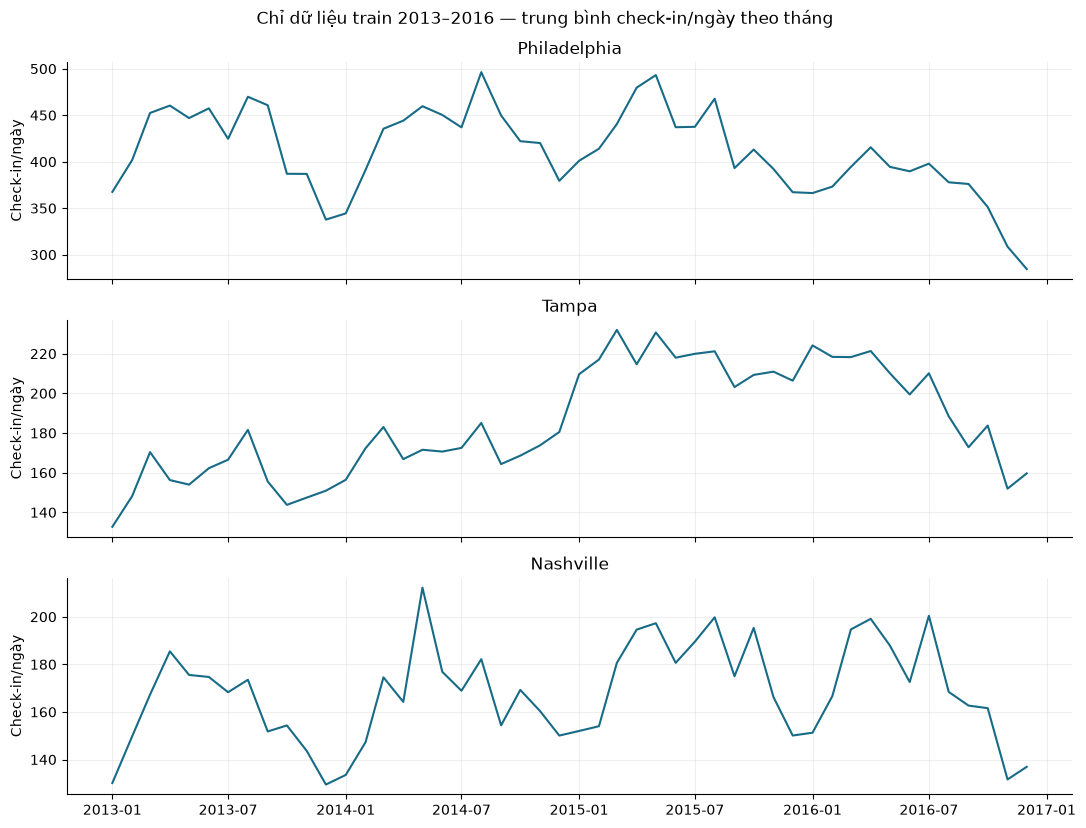

In [7]:
train_activity = panel.loc[panel["date"] <= pd.Timestamp(COHORT_END)]
monthly_activity = (
    train_activity.assign(month=train_activity["date"].dt.to_period("M").dt.to_timestamp())
    .groupby(["city", "month"], as_index=False)["y"]
    .mean()
)
fig, axes = plt.subplots(len(CITIES), 1, figsize=(11, 2.8 * len(CITIES)), sharex=True)
for scope, ax in zip(CITIES, np.atleast_1d(axes), strict=True):
    rows = monthly_activity.loc[monthly_activity["city"] == scope.city]
    ax.plot(rows["month"], rows["y"], color="#176b87")
    ax.set(title=scope.city, ylabel="Check-in/ngày")
    ax.grid(alpha=0.2)
fig.suptitle("Chỉ dữ liệu train 2013–2016 — trung bình check-in/ngày theo tháng")
fig.tight_layout()
activity_figure = fig
plt.show()

### 5. Tạo gợi ý mà không nhìn đáp án hôm nay

`y_lag_1` là check-in hôm qua; `y_lag_7` là cùng ngày tuần trước.
`y_mean_28` là trung bình 28 ngày **đã qua**, không gồm hôm nay.
Chúng ta tính riêng cho từng thành phố để không lấy số của Tampa đưa sang Philadelphia.

Bỏ 28 ngày đầu vì chưa đủ lịch sử. Hai phiên bản weather/no-weather dùng cùng các dòng còn lại.

In [8]:
features = build_features(panel)
display(features[["city", "date", "y", "y_lag_1", "y_lag_7", "y_mean_28"]].head(7))
print("Offset của từng lag (ngày):", features.attrs["lag_offsets_days"])
print("Số dòng đủ lịch sử:", len(features))

,city,date,y,y_lag_1,y_lag_7,y_mean_28
0,Nashville,2013-01-29,113,92.0,86.0,131.107143
1,Nashville,2013-01-30,140,113.0,110.0,129.428571
2,Nashville,2013-01-31,110,140.0,130.0,131.500000
3,Nashville,2013-02-01,136,110.0,116.0,131.892857
4,Nashville,2013-02-02,216,136.0,192.0,133.071429
5,Nashville,2013-02-03,173,216.0,148.0,135.107143
6,Nashville,2013-02-04,78,173.0,92.0,135.500000


Offset của từng lag (ngày): {1: 1, 7: 7, 14: 14, 28: 28}
Số dòng đủ lịch sử: 9777


### 6. Các bạn tham gia cuộc thi

| Cách đoán | Giải thích dễ hiểu |
|---|---|
| Seasonal naive | “Thứ Hai tới có thể giống Thứ Hai tuần trước.” |
| Recent mean | “Lấy trung bình của 28 ngày vừa qua.” |
| Zero | “Ngày nào cũng đoán 0.” Chỉ là đối chứng để phát hiện bài toán quá thưa. |
| Poisson GLM | Học một công thức chuyên dự đoán **số đếm kỳ vọng** từ các gợi ý. |
| Histogram Gradient Boosting | Nhiều cây hỏi các câu như “gần đây hoạt động cao không?”, rồi sửa lỗi cho nhau. |
| CatBoost | Một nhóm cây khác, có cách học các nhãn như thành phố và thứ trong tuần. |

Ba model học máy đều có bản không weather và bản observed weather. Mỗi bản được thử **hai cấu hình**
trên validation; không thử hàng trăm lần để tình cờ được điểm đẹp. Seed cố định giúp lặp lại thí nghiệm.

In [9]:
candidates = candidate_configs(FAMILIES)
display(pd.DataFrame([config.to_dict() for config in candidates]))
print("Số cấu hình thử:", len(candidates), "— mỗi cấu hình có", len(FOLDS), "validation folds.")

,family,mode,params,candidate
0,seasonal_naive7,no_weather,{},default
1,recent_mean28,no_weather,{},default
2,zero,no_weather,{},default
3,poisson,no_weather,{'alpha': 0.1},c1
4,poisson,no_weather,{'alpha': 1.0},c2
5,poisson,observed_weather,{'alpha': 0.1},c1
6,poisson,observed_weather,{'alpha': 1.0},c2
7,hist_gradient_boosting,no_weather,"{'max_iter': 150, 'max_leaf_nodes': 15, 'learn...",c1
8,hist_gradient_boosting,no_weather,"{'max_iter': 250, 'max_leaf_nodes': 31, 'learn...",c2
9,hist_gradient_boosting,observed_weather,"{'max_iter': 150, 'max_leaf_nodes': 15, 'learn...",c1


Số cấu hình thử: 15 — mỗi cấu hình có 2 validation folds.


### 7. Chấm điểm như thế nào?

- **MAE:** trung bình đoán lệch bao nhiêu check-in. Ví dụ lệch 1, 1, 0 thì MAE = 2/3.
- **RMSE:** phạt lỗi rất lớn mạnh hơn. Thấp hơn tốt hơn.
- **Poisson deviance:** điểm phạt dành cho số đếm kỳ vọng. Thấp hơn tốt hơn;
  đây là điểm chính để chọn model.

“Số đếm kỳ vọng” giống trung bình của rất nhiều ngày có cùng điều kiện. Vì vậy dự đoán 2,5 check-in
là hợp lệ: đó là mức trung bình, không phải một sự kiện bị chia đôi.

Vì sao không chỉ chọn MAE? Một nơi thường có zero có thể làm bạn “luôn đoán 0” được MAE thấp,
dù cách đó bỏ qua những ngày có hoạt động. Dự đoán kỳ vọng và dự đoán giá trị thường gặp nhất là hai việc khác nhau.
Nếu dự đoán 0 trong ngày thực tế có check-in, deviance là vô hạn; code không đổi 0 thành số nhỏ để làm đẹp điểm.

`macro_city` là chấm từng thành phố rồi lấy trung bình. `pooled` gộp mọi dòng.
Deviance vẫn phụ thuộc quy mô số đếm, nên luôn xem thêm từng thành phố và mức cải thiện tương đối.

In [10]:
toy_scores = count_metrics(np.array([2, 4, 6]), np.array([1, 5, 6]))
display(pd.DataFrame([toy_scores]).round(3))
print("Đối chứng zero có deviance:", count_metrics([2, 4, 6], [0, 0, 0])["mean_poisson_deviance"])

,mean_poisson_deviance,mae,rmse,actual_total,predicted_total,relative_total_error
0,0.329,0.667,0.816,12.0,12.0,0.0


Đối chứng zero có deviance: inf


### 8. Kiểm tra thử và khóa cấu hình

Mọi model dự đoán cùng city-days. Scaler/encoder chỉ học trên train của từng fold.
Model không tự tạo một random validation set; validation được chia bằng ngày rõ ràng.
Sau bước này, cấu hình được khóa **trước khi đọc điểm test 2019**.

In [11]:
prepared = {key: data_manifest["config"][key] for key in current_data_settings()}
if current_data_settings() != prepared:
    raise ValueError("Tham số khác dữ liệu đã load. Hãy Restart Kernel and Run All.")
frozen_protocol = current_protocol_settings()
training_started = perf_counter()
validation = compare_validation(features, FOLDS, seed=SEED, families=FAMILIES)
selected_configs = validation.selected_configs
selected_ids = [config.config_id for config in selected_configs]
validation_scores = (
    validation.metrics.loc[
        (validation.metrics["scope"] == "macro_city")
        & (validation.metrics["fold"] != "all_validation")
        & validation.metrics["config_id"].isin(selected_ids)
    ]
    .groupby(["model_id", "config_id", "family", "mode"], as_index=False)[
        ["mean_poisson_deviance", "mae", "rmse"]
    ]
    .mean()
    .sort_values(["mean_poisson_deviance", "model_id"], kind="stable")
)
finite_validation = validation_scores.loc[np.isfinite(validation_scores["mean_poisson_deviance"])]
if finite_validation.empty:
    raise ValueError("Không có mô hình với deviance hữu hạn để chọn trên validation.")
champion_id = finite_validation.iloc[0]["model_id"]
print("Model chọn bằng validation:", champion_id)
display(validation_scores.round(3))
display(pd.DataFrame([config.to_dict() for config in selected_configs]))

Model chọn bằng validation: hist_gradient_boosting__no_weather


,model_id,config_id,family,mode,mean_poisson_deviance,mae,rmse
2,hist_gradient_boosting__no_weather,hist_gradient_boosting__no_weather__c2,hist_gradient_boosting,no_weather,4.917,21.462,29.428
3,hist_gradient_boosting__observed_weather,hist_gradient_boosting__observed_weather__c2,hist_gradient_boosting,observed_weather,5.037,21.723,29.925
0,catboost__no_weather,catboost__no_weather__c2,catboost,no_weather,7.802,27.061,37.256
1,catboost__observed_weather,catboost__observed_weather__c2,catboost,observed_weather,8.012,26.840,37.388
5,poisson__observed_weather,poisson__observed_weather__c1,poisson,observed_weather,8.692,30.949,37.973
4,poisson__no_weather,poisson__no_weather__c1,poisson,no_weather,9.007,31.572,38.712
7,seasonal_naive7__no_weather,seasonal_naive7__no_weather__default,seasonal_naive7,no_weather,9.974,27.973,40.263
6,recent_mean28__no_weather,recent_mean28__no_weather__default,recent_mean28,no_weather,24.378,55.535,65.969
8,zero__no_weather,zero__no_weather__default,zero,no_weather,inf,169.668,182.970


,family,mode,params,candidate
0,seasonal_naive7,no_weather,{},default
1,recent_mean28,no_weather,{},default
2,zero,no_weather,{},default
3,poisson,no_weather,{'alpha': 0.1},c1
4,poisson,observed_weather,{'alpha': 0.1},c1
5,hist_gradient_boosting,no_weather,"{'max_iter': 250, 'max_leaf_nodes': 31, 'learn...",c2
6,hist_gradient_boosting,observed_weather,"{'max_iter': 250, 'max_leaf_nodes': 31, 'learn...",c2
7,catboost,no_weather,"{'iterations': 350, 'depth': 6, 'learning_rate...",c2
8,catboost,observed_weather,"{'iterations': 350, 'depth': 6, 'learning_rate...",c2


### 9. Bài kiểm tra cuối năm 2019

Học lại với dữ liệu đến 30/12/2018, dùng cấu hình đã khóa rồi dự đoán 2019.
Bảng giữ thứ tự validation; xem điểm test để đánh giá, **không đổi cấu hình vì điểm test**.
Actual của ngày test đã qua có thể trở thành lag cho ngày kế tiếp: đó là quy tắc rolling một ngày đã nêu từ đầu.

In [12]:
if current_protocol_settings() != frozen_protocol:
    raise ValueError("Luật đã đổi sau validation. Hãy Restart Kernel and Run All.")
test = evaluate_holdout(
    features, selected_configs, FINAL_TRAIN_END, TEST_START, TEST_END, split="test", seed=SEED
)
order = validation_scores["model_id"].tolist()
test_table = (
    test.metrics.loc[test.metrics["scope"] == "macro_city"]
    .set_index("model_id")
    .loc[order]
    .reset_index()
)
display(test_table[["model_id", "mean_poisson_deviance", "mae", "rmse", "fit_seconds"]].round(3))
print("Đơn vị: số check-in ghi nhận của cohort thành phố/ngày; không phải số khách.")

,model_id,mean_poisson_deviance,mae,rmse,fit_seconds
0,hist_gradient_boosting__no_weather,3.493,15.564,20.591,0.685
1,hist_gradient_boosting__observed_weather,3.695,15.981,21.028,0.693
2,catboost__no_weather,3.873,16.366,21.550,1.751
3,catboost__observed_weather,4.140,16.820,21.965,2.220
4,poisson__observed_weather,10.190,30.729,34.865,0.057
5,poisson__no_weather,10.197,30.656,34.865,0.057
6,seasonal_naive7__no_weather,7.751,22.076,29.926,0.000
7,recent_mean28__no_weather,18.205,39.648,47.122,0.000
8,zero__no_weather,inf,117.231,126.870,0.000


Đơn vị: số check-in ghi nhận của cohort thành phố/ngày; không phải số khách.


### 10. Weather có giúp không?

So từng cặp cùng họ model: không weather và observed weather. Số dương nghĩa là weather giảm lỗi.
Cấu hình mỗi bản được chọn riêng với ngân sách validation bằng nhau; không gọi đây là so sánh cùng tham số.
Bảng thứ hai tách thành phố để nhìn xem một nơi lớn có che lấp nơi khác không.

In [13]:
weather_uplift = paired_weather_uplift(
    test.predictions, block_days=BLOCK_DAYS, n_bootstrap=BOOTSTRAP_DRAWS, seed=SEED
)
city_metric_rows = test.metrics.loc[
    (test.metrics["scope"] == "city")
    & test.metrics["family"].isin(["poisson", "hist_gradient_boosting", "catboost"])
]
if weather_uplift.empty:
    print("Chưa có cặp model weather/no-weather để so; thêm một họ học máy vào FAMILIES.")
    city_pairs = pd.DataFrame(
        columns=["city", "family", "no_weather", "observed_weather", "weather_reduction_pct"]
    ).set_index(["city", "family"])
else:
    display(weather_uplift.round(3))
    city_pairs = city_metric_rows.pivot(
        index=["city", "family"], columns="mode", values="mean_poisson_deviance"
    )
    city_pairs["weather_reduction_pct"] = (
        100
        * (city_pairs["no_weather"] - city_pairs["observed_weather"])
        / city_pairs["no_weather"].where(city_pairs["no_weather"] > 0)
    )
    display(city_pairs.round(3))

,split,family,scope,deviance_reduction,deviance_reduction_pct,empirical_ci_lower,empirical_ci_upper,block_days,n_bootstrap,n_dates,n_cities
0,test,catboost,macro_city,-0.267,-6.890,-0.461,-0.043,14,200,365,3
1,test,hist_gradient_boosting,macro_city,-0.202,-5.792,-0.348,-0.081,14,200,365,3
2,test,poisson,macro_city,0.007,0.068,-0.149,0.160,14,200,365,3


mode                                 no_weather  observed_weather  \
city         family                                                 
Nashville    catboost                     5.024             5.540   
             hist_gradient_boosting       4.230             4.615   
             poisson                     13.105            13.141   
Philadelphia catboost                     4.518             4.677   
             hist_gradient_boosting       4.269             4.422   
             poisson                      7.249             7.426   
Tampa        catboost                     2.078             2.204   
             hist_gradient_boosting       1.980             2.049   
             poisson                     10.237            10.003   

mode                                 weather_reduction_pct  
city         family                                         
Nashville    catboost                              -10.253  
             hist_gradient_boosting                 -9.108  
             poisson                                -0.280  
Philadelphia catboost                               -3.524  
             hist_gradient_boosting                 -3.577  
             poisson                                -2.440  
Tampa        catboost                               -6.078  
             hist_gradient_boosting                 -3.482  
             poisson                                 2.288

### 11. Vì sao có một đoạn khoảng bên cạnh điểm cải thiện?

Một tuần mưa ảnh hưởng nhiều thành phố/ngày cùng lúc. Không coi từng dòng như một lần tung đồng xu độc lập.
Chúng ta chia lịch test thành các mảnh 14 ngày, lấy lại các mảnh nhiều lần và tính lại chênh lệch.
Đoạn 95% là **khoảng thực nghiệm của chênh lệch lỗi** theo cách lấy mẫu này.
Nó không phải khoảng dự đoán số check-in ngày mai, chưa bảo đảm đúng dưới mọi thay đổi dữ liệu.

Nếu đoạn đi qua 0, bằng chứng weather tốt hơn chưa ổn định theo phép kiểm tra này.
Không biến kết quả này thành khẳng định weather gây tăng/giảm khách.

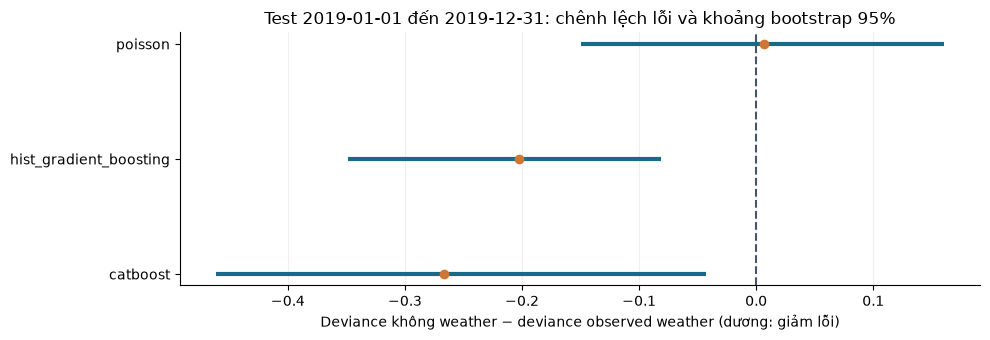

In [14]:
uplift_figure = None
if weather_uplift.empty:
    print("Không vẽ weather uplift vì chưa có cặp model.")
else:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    for index, row in weather_uplift.reset_index(drop=True).iterrows():
        ax.hlines(
            index,
            row["empirical_ci_lower"],
            row["empirical_ci_upper"],
            color="#176b87",
            linewidth=3,
        )
        ax.scatter(row["deviance_reduction"], index, color="#ce7634", zorder=3)
    ax.axvline(0, color="#475569", linestyle="--")
    ax.set_yticks(range(len(weather_uplift)), weather_uplift["family"])
    ax.set(
        xlabel="Deviance không weather − deviance observed weather (dương: giảm lỗi)",
        title=f"Test {TEST_START} đến {TEST_END}: chênh lệch lỗi và khoảng bootstrap 95%",
    )
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    uplift_figure = fig
    plt.show()

### 12. Xem đường đoán và đường thực tế

Chúng ta vẽ model được chọn bằng validation, chưa đổi sang model đứng đầu test.
Biểu đồ dùng trung bình tháng cho dễ nhìn; metrics vẫn chấm từng ngày.
Chưa dựng khoảng dự đoán đã hiệu chuẩn, nên không vẽ dải “chắc chắn” quanh đường dự đoán.

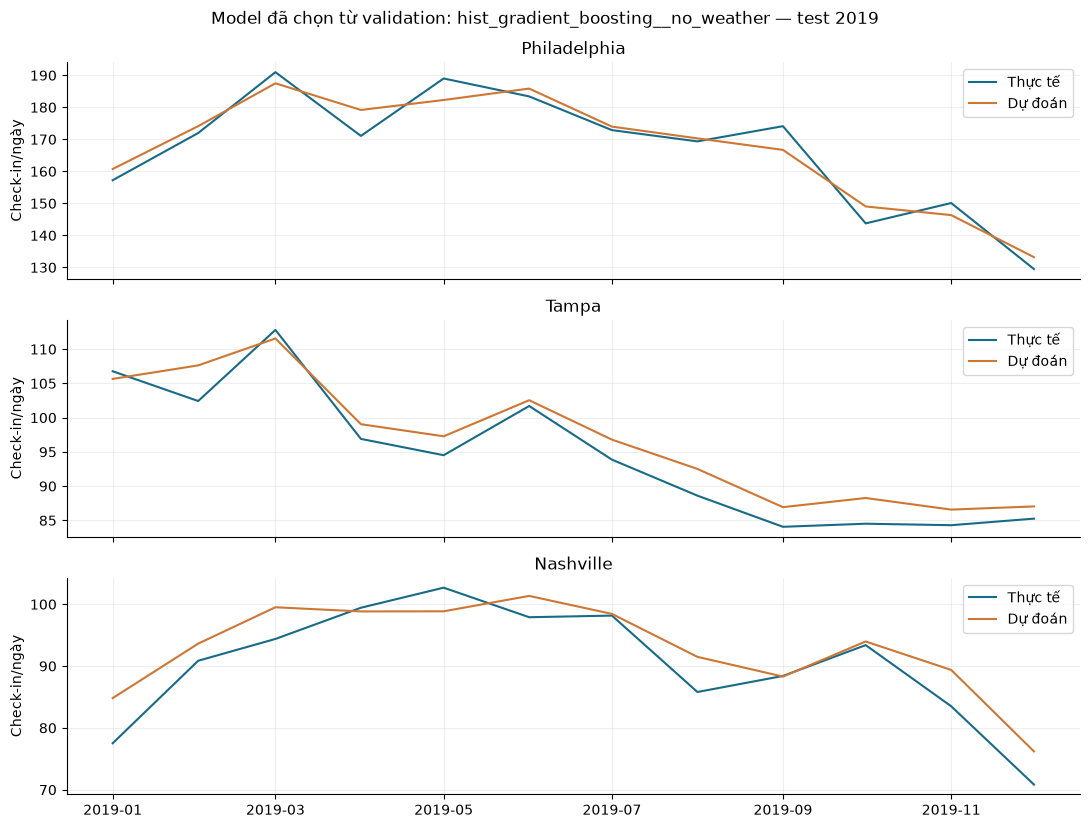

In [15]:
champion_predictions = test.predictions.loc[test.predictions["model_id"] == champion_id].copy()
champion_predictions["month"] = champion_predictions["date"].dt.to_period("M").dt.to_timestamp()
monthly_predictions = champion_predictions.groupby(["city", "month"], as_index=False)[
    ["y", "y_pred"]
].mean()
fig, axes = plt.subplots(len(CITIES), 1, figsize=(11, 2.8 * len(CITIES)), sharex=True)
for scope, ax in zip(CITIES, np.atleast_1d(axes), strict=True):
    rows = monthly_predictions.loc[monthly_predictions["city"] == scope.city]
    ax.plot(rows["month"], rows["y"], label="Thực tế", color="#176b87")
    ax.plot(rows["month"], rows["y_pred"], label="Dự đoán", color="#ce7634")
    ax.set(title=scope.city, ylabel="Check-in/ngày")
    ax.legend()
    ax.grid(alpha=0.2)
fig.suptitle(f"Model đã chọn từ validation: {champion_id} — test 2019")
fig.tight_layout()
prediction_figure = fig
plt.show()

### 13. Bài kiểm tra giai đoạn khó: 2020–2021

Giữ cấu hình và mốc học đến 2018, xem model hoạt động ra sao trong 2020–2021.
Chỉ lịch sử check-in được cập nhật từng ngày theo giả định đã nêu. Chấm riêng từng năm,
không dùng phần này để chọn model. Không suy rằng mọi thay đổi là do weather hoặc COVID.

In [16]:
stress = None
stress_year_metrics = pd.DataFrame()
if RUN_STRESS_TEST:
    stress = evaluate_holdout(
        features,
        selected_configs,
        FINAL_TRAIN_END,
        STRESS_START,
        STRESS_END,
        split="stress",
        seed=SEED,
    )
    yearly_rows = []
    for (year, model_id, city), rows in stress.predictions.groupby(
        [stress.predictions["date"].dt.year, "model_id", "city"], sort=True
    ):
        yearly_rows.append(
            {
                "year": year,
                "model_id": model_id,
                "city": city,
                **count_metrics(rows["y"], rows["y_pred"]),
            }
        )
    stress_year_metrics = pd.DataFrame(yearly_rows)
    display(
        stress_year_metrics.groupby(["year", "model_id"])[["mean_poisson_deviance", "mae", "rmse"]]
        .mean()
        .round(3)
    )
else:
    print("Stress test đã tắt trong tham số; chưa được đánh giá ở lần chạy này.")

mean_poisson_deviance     mae  \
year model_id                                                                  
2020 catboost__no_weather                                     40.002  40.698   
     catboost__observed_weather                               46.742  46.183   
     hist_gradient_boosting__no_weather                       34.753  36.719   
     hist_gradient_boosting__observed_weather                 33.173  35.332   
     poisson__no_weather                                      75.878  70.195   
     poisson__observed_weather                                76.718  70.853   
     recent_mean28__no_weather                                11.874  17.719   
     seasonal_naive7__no_weather                               6.892  12.233   
     zero__no_weather                                            inf  40.642   
2021 catboost__no_weather                                     24.717  34.191   
     catboost__observed_weather                               30.174  40.367   
     hist_gradient_boosting__no_weather                       20.077  29.045   
     hist_gradient_boosting__observed_weather                 19.044  27.741   
     poisson__no_weather                                      56.991  65.513   
     poisson__observed_weather                                57.431  65.917   
     recent_mean28__no_weather                                 7.426  14.479   
     seasonal_naive7__no_weather                               4.257   9.760   
     zero__no_weather                                            inf  41.295   

                                                 rmse  
year model_id                                          
2020 catboost__no_weather                      45.212  
     catboost__observed_weather                50.799  
     hist_gradient_boosting__no_weather        40.652  
     hist_gradient_boosting__observed_weather  39.408  
     poisson__no_weather                       75.413  
     poisson__observed_weather                 76.134  
     recent_mean28__no_weather                 26.060  
     seasonal_naive7__no_weather               20.218  
     zero__no_weather                          55.256  
2021 catboost__no_weather                      36.761  
     catboost__observed_weather                42.203  
     hist_gradient_boosting__no_weather        31.726  
     hist_gradient_boosting__observed_weather  30.560  
     poisson__no_weather                       68.179  
     poisson__observed_weather                 68.608  
     recent_mean28__no_weather                 17.892  
     seasonal_naive7__no_weather               12.897  
     zero__no_weather                          45.737

### 14. Thử giả định timestamp còn lại

Chúng ta xây lại **cả check-in theo ngày, cohort và weather join**, không chỉ đổi nhãn ngày.
Giữ cấu hình model đã khóa và refit theo cùng cutoff. Bảng này đo độ nhạy của pipeline với giả định;
không chứng minh local hay UTC đúng, không dùng test để chọn timezone.
Nếu doanh nghiệp sát ngưỡng eligibility đổi nhóm, chênh lệch bao gồm cả thay đổi cohort và ngày ghi nhận.

In [17]:
timezone_sensitivity = None
alternate_manifest = None
alternate_cohort = None
if RUN_TIMEZONE_SENSITIVITY:
    alternate_assumption = "utc" if TIMESTAMP_ASSUMPTION == "local" else "local"
    alternate_panel, alternate_cohort, alternate_manifest = prepare_city_panel(
        ROOT,
        CITIES,
        CATEGORY,
        START_DATE,
        END_DATE,
        COHORT_END,
        min_train_checkins=MIN_TRAIN_CHECKINS,
        timestamp_assumption=alternate_assumption,
    )
    alternate_features = build_features(alternate_panel)
    timezone_sensitivity = evaluate_holdout(
        alternate_features,
        selected_configs,
        FINAL_TRAIN_END,
        TEST_START,
        TEST_END,
        split="timezone_sensitivity",
        seed=SEED,
    )
    sensitivity_table = timezone_sensitivity.metrics.loc[
        timezone_sensitivity.metrics["scope"] == "macro_city"
    ][["model_id", "mean_poisson_deviance", "mae"]]
    display(
        test_table[["model_id", "mean_poisson_deviance", "mae"]]
        .merge(
            sensitivity_table,
            on="model_id",
            validate="one_to_one",
            suffixes=(f"_{TIMESTAMP_ASSUMPTION}", f"_{alternate_assumption}"),
        )
        .round(3)
    )
    changed_ids = set(cohort["business_id"]) ^ set(alternate_cohort["business_id"])
    print("Số business thay đổi eligibility giữa hai giả định:", len(changed_ids))
    display(
        pd.concat(
            [
                cohort.groupby("city")["business_id"].nunique().rename(TIMESTAMP_ASSUMPTION),
                alternate_cohort.groupby("city")["business_id"]
                .nunique()
                .rename(alternate_assumption),
            ],
            axis=1,
        )
    )
else:
    print("Timezone sensitivity đã tắt; kết quả chỉ theo giả định", TIMESTAMP_ASSUMPTION)

,model_id,mean_poisson_deviance_local,mae_local,mean_poisson_deviance_utc,mae_utc
0,hist_gradient_boosting__no_weather,3.493,15.564,3.693,16.256
1,hist_gradient_boosting__observed_weather,3.695,15.981,3.932,16.578
2,catboost__no_weather,3.873,16.366,4.068,16.949
3,catboost__observed_weather,4.140,16.820,4.618,18.059
4,poisson__observed_weather,10.190,30.729,10.456,30.609
5,poisson__no_weather,10.197,30.656,10.434,30.566
6,seasonal_naive7__no_weather,7.751,22.076,8.128,22.782
7,recent_mean28__no_weather,18.205,39.648,16.668,37.168
8,zero__no_weather,inf,117.231,inf,117.220


Số business thay đổi eligibility giữa hai giả định: 0


,local,utc
city,,
Nashville,1140,1140
Philadelphia,2548,2548
Tampa,1379,1379


### 15. Nếu dữ liệu hôm qua chưa đến thì sao?

Thử chậm thêm một ngày: gợi ý ngắn hạn mới nhất lấy từ hai ngày trước.
Gợi ý cùng thứ tuần trước vẫn dùng được vì nó đã đủ cũ.
Cấu hình giữ nguyên và refit trên train; không tuning lại bằng điểm test.
Đây là kiểm tra một giả định về độ trễ, chưa đo được độ trễ thật của Yelp.
Mốc học cũng lùi thêm một ngày, để không học từ đáp án chưa kịp được nhận.


In [18]:
delay_sensitivity = None
if RUN_REPORTING_DELAY_SENSITIVITY:
    delayed_features = build_features(panel, extra_reporting_delay_days=1)
    delayed_train_end = (
        min(pd.Timestamp(FINAL_TRAIN_END), pd.Timestamp(TEST_START) - pd.Timedelta(days=3))
        .date()
        .isoformat()
    )
    print("Mốc học khi dữ liệu chậm thêm một ngày:", delayed_train_end)
    delay_sensitivity = evaluate_holdout(
        delayed_features,
        selected_configs,
        delayed_train_end,
        TEST_START,
        TEST_END,
        split="reporting_delay_sensitivity",
        seed=SEED,
    )
    display(
        test_table[["model_id", "mean_poisson_deviance", "mae"]]
        .merge(
            delay_sensitivity.metrics.loc[
                delay_sensitivity.metrics["scope"] == "macro_city",
                ["model_id", "mean_poisson_deviance", "mae"],
            ],
            on="model_id",
            validate="one_to_one",
            suffixes=("_default", "_extra_day_delay"),
        )
        .round(3)
    )
    print("Lag offsets thực tế:", delayed_features.attrs["lag_offsets_days"])
else:
    print("Reporting-delay sensitivity đã tắt; chưa đánh giá giả định dữ liệu chậm hơn.")

Mốc học khi dữ liệu chậm thêm một ngày: 2018-12-29


,model_id,mean_poisson_deviance_default,mae_default,mean_poisson_deviance_extra_day_delay,mae_extra_day_delay
0,hist_gradient_boosting__no_weather,3.493,15.564,3.973,16.318
1,hist_gradient_boosting__observed_weather,3.695,15.981,4.349,17.256
2,catboost__no_weather,3.873,16.366,4.540,17.318
3,catboost__observed_weather,4.140,16.820,4.645,17.771
4,poisson__observed_weather,10.190,30.729,10.225,30.911
5,poisson__no_weather,10.197,30.656,10.214,30.784
6,seasonal_naive7__no_weather,7.751,22.076,7.751,22.076
7,recent_mean28__no_weather,18.205,39.648,18.324,39.765
8,zero__no_weather,inf,117.231,inf,117.231


Lag offsets thực tế: {1: 2, 7: 7, 14: 14, 28: 28}


## Checks — Kiểm tra lại cuộc thi có công bằng không

Cùng keys, cùng đáp án; không có dòng bị mất trong một phiên bản weather.
Kiểm tra mọi model có đủ ngày test ở mỗi thành phố. Predictions phải là số hữu hạn, không âm.
Zero có deviance vô hạn là kết quả hợp lệ; không phải lỗi để che đi.

In [19]:
expected_keys = features.loc[features["date"].between(TEST_START, TEST_END), ["city", "date"]]
for _model_id, rows in test.predictions.groupby("model_id"):
    actual_keys = rows[["city", "date"]].sort_values(["city", "date"]).reset_index(drop=True)
    pd.testing.assert_frame_equal(
        actual_keys, expected_keys.sort_values(["city", "date"]).reset_index(drop=True)
    )
    assert not rows.duplicated(["city", "date"]).any()
    assert np.isfinite(rows["y_pred"]).all() and rows["y_pred"].ge(0).all()
assert len(selected_configs) == test.predictions["model_id"].nunique()
print("Đã kiểm tra cùng target keys, số ngày và miền giá trị dự đoán.")

Đã kiểm tra cùng target keys, số ngày và miền giá trị dự đoán.


### Lưu bài làm để người khác kiểm tra lại

Lưu bảng điểm, predictions, danh sách doanh nghiệp, cấu hình và hash file nguồn.
Model binary được tạo bởi chính lần chạy này. Các artifact nằm dưới `data/processed/`, không đưa vào Git.
Mã experiment nhận diện dữ liệu/cấu hình/code/lockfile. Mỗi lần chạy có folder thời gian riêng;
chạy lại không ghi đè bundle đã hoàn tất. Phần lưu bên dưới là nâng cao, chưa cần sửa để học các model.
JSON cuối được đánh dấu complete chỉ sau khi export thành công.

In [20]:
if current_protocol_settings() != frozen_protocol:
    raise ValueError("Tham số đã đổi sau validation. Hãy Restart Kernel and Run All.")
import joblib

run_config = {
    "cities": [asdict(scope) for scope in CITIES],
    "category": CATEGORY,
    "start_date": START_DATE,
    "end_date": END_DATE,
    "cohort_end": COHORT_END,
    "min_train_checkins": MIN_TRAIN_CHECKINS,
    "timestamp_assumption": TIMESTAMP_ASSUMPTION,
    "seed": SEED,
    "folds": [asdict(fold) for fold in FOLDS],
    "final_train_end": FINAL_TRAIN_END,
    "test": [TEST_START, TEST_END],
    "stress": [STRESS_START, STRESS_END],
    "families": list(FAMILIES),
    "run_stress": RUN_STRESS_TEST,
    "run_timezone_sensitivity": RUN_TIMEZONE_SENSITIVITY,
    "run_reporting_delay_sensitivity": RUN_REPORTING_DELAY_SENSITIVITY,
    "block_days": BLOCK_DAYS,
    "bootstrap_draws": BOOTSTRAP_DRAWS,
    "forecast_protocol": "one-day rolling origin; previous completed day assumed available",
    "shared_fit_gap_days": 1,
    "reporting_delay_train_end": (delayed_train_end if RUN_REPORTING_DELAY_SENSITIVITY else None),
    "weather_protocol": "realized target-date ERA5; retrospective conditional prediction",
    "primary_selection_metric": "equal-fold mean macro-city Poisson deviance",
    "selected_configs": [config.to_dict() for config in selected_configs],
    "champion_selected_on_validation": champion_id,
}
code_hashes = {
    str(path.relative_to(ROOT)): hashlib.sha256(path.read_bytes()).hexdigest()
    for path in [
        ROOT / "src/sitesense/forecast_data.py",
        ROOT / "src/sitesense/forecast_models.py",
        ROOT / "uv.lock",
        ROOT / "notebooks/03_forecasting_model_comparison.ipynb",
    ]
}
identity = {
    "config": run_config,
    "data": data_manifest["dataset_version"],
    "alternate_data": None if alternate_manifest is None else alternate_manifest["dataset_version"],
    "code_hashes": code_hashes,
    "packages": experiment_versions(),
}
experiment_id = hashlib.sha256(json.dumps(identity, sort_keys=True).encode()).hexdigest()[:16]
run_id = experiment_id + "_" + datetime.now(UTC).strftime("%Y%m%dT%H%M%S%fZ")
output_dir = OUTPUT_ROOT / run_id
output_dir.mkdir(parents=True, exist_ok=False)
manifest_path = output_dir / "experiment_manifest.json"
manifest_path.write_text(json.dumps({"status": "running", "run_id": run_id}))

tables = {
    "city_daily_panel": panel,
    "cohort": cohort,
    "validation_metrics": validation.metrics,
    "validation_predictions": validation.predictions,
    "test_metrics": test.metrics,
    "test_predictions": test.predictions,
    "weather_uplift": weather_uplift,
    "per_city_weather_comparison": city_pairs.reset_index(),
}
if stress is not None:
    tables.update(
        stress_metrics=stress.metrics,
        stress_predictions=stress.predictions,
        stress_year_metrics=stress_year_metrics,
    )
if timezone_sensitivity is not None:
    tables.update(
        timezone_metrics=timezone_sensitivity.metrics,
        timezone_predictions=timezone_sensitivity.predictions,
        alternate_cohort=alternate_cohort,
    )
if delay_sensitivity is not None:
    tables.update(
        reporting_delay_metrics=delay_sensitivity.metrics,
        reporting_delay_predictions=delay_sensitivity.predictions,
    )
for name, table in tables.items():
    table.to_csv(output_dir / f"{name}.csv", index=False)
for name, figure in [
    ("activity", activity_figure),
    ("weather_uplift", uplift_figure),
    ("test_predictions", prediction_figure),
]:
    if figure is not None:
        figure.savefig(output_dir / f"{name}.png", dpi=150, bbox_inches="tight")
joblib.dump(
    {
        "models": test.fitted_models,
        "selected_configs": run_config["selected_configs"],
        "run_id": run_id,
        "packages": experiment_versions(),
    },
    output_dir / "models.joblib",
)
manifest = {
    "status": "complete",
    "run_id": run_id,
    "experiment_id": experiment_id,
    "config": run_config,
    "data": data_manifest,
    "alternate_data": alternate_manifest,
    "code_hashes": code_hashes,
    "packages": experiment_versions(),
    "python": platform.python_version(),
    "completed_at_utc": datetime.now(UTC).isoformat(),
    "preparation_seconds": preparation_seconds,
    "analysis_seconds_since_validation_start": perf_counter() - training_started,
    "artifact_files": sorted(path.name for path in output_dir.iterdir()),
    "limits": [
        "timezone unverified",
        "static Yelp metadata",
        "activity proxy only",
        "no spatial/cold-start benchmark",
        "no calibrated count prediction intervals",
        "observed weather is unavailable to a real future forecaster",
    ],
}
manifest_path = output_dir / "experiment_manifest.json"
temporary_manifest = manifest_path.with_suffix(".json.tmp")
temporary_manifest.write_text(
    json.dumps(manifest, indent=2, ensure_ascii=False, allow_nan=False) + "\n"
)
temporary_manifest.replace(manifest_path)
print("Kết quả đã lưu:", output_dir.relative_to(ROOT))

Kết quả đã lưu: data/processed/forecast_comparison/ced22da0f342caba_20261007T131559499276Z


## Next Steps — Đọc kết quả như một nhà nghiên cứu nhỏ

Bảng bên dưới được tính từ **lần chạy hiện tại**, không ghi sẵn model thắng.
“Weather không giúp” cũng là một câu trả lời có ích. Đừng đổi luật cuộc thi sau khi biết đáp án.

In [ ]:
champion_test = test_table.loc[test_table["model_id"] == champion_id].iloc[0]
lines = [
    f"**Model chọn trên validation:** `{champion_id}`.",
    f"**Test {TEST_START}–{TEST_END}:** macro-city deviance = "
    f"{champion_test['mean_poisson_deviance']:.3f}; "
    f"MAE = {champion_test['mae']:.3f} check-in/ngày.",
]
for _, row in weather_uplift.iterrows():
    direction = "giảm" if row["deviance_reduction_pct"] >= 0 else "tăng"
    lines.append(
        f"**{row['family']}:** observed weather {direction} lỗi "
        f"{abs(row['deviance_reduction_pct']):.2f}%; "
        f"khoảng bootstrap của mức giảm deviance "
        f"[{row['empirical_ci_lower']:.3f}, {row['empirical_ci_upper']:.3f}]."
    )
lines.append(
    "Các số trên áp dụng cho cohort và giả định timestamp đã chọn; "
    "không phải số khách hoặc tác động nhân quả."
)
display(Markdown("\n\n".join(lines)))

### Bài tập nhỏ

1. Giải thích vì sao không được chọn doanh nghiệp bằng số check-in của năm test.
2. Tìm một thành phố nơi weather giúp ít hơn thành phố khác. Dữ liệu có đủ để nói nguyên nhân không?
3. So hai giả định timezone và trường hợp dữ liệu chậm một ngày. Kết luận nào còn đứng vững?
4. Nếu muốn thử ngành khác hoặc thành phố khác, chốt cấu hình trước rồi chạy lại từ đầu.
5. Nếu muốn dự báo thực tế với weather, cần **forecast đã phát hành trước ngày cần đoán**,
   có ngày/giờ phát hành và horizon; không thay ERA5 bằng forecast hiện tại cho các ngày test quá khứ.

Sau thí nghiệm temporal này, có thể thêm kiểm tra thành phố chưa thấy hoặc những đợt weather cực đoan.
Các bài đó chưa được notebook này đánh giá. Kết quả ở cấp thành phố chưa chứng minh khả năng chọn địa chỉ mở cửa hàng.

### Nguồn và phần “dưới nắp máy”

- [Định nghĩa và audit dataset](../docs/research/dataset-audit.md), [weather source/schema](../docs/weather-data.md).
- [Data preparation](../src/sitesense/forecast_data.py) và [model/evaluation helpers](../src/sitesense/forecast_models.py).
- [scikit-learn: Poisson/count regression](https://scikit-learn.org/stable/auto_examples/linear_model/plot_poisson_regression_non_normal_loss.html).
- [scikit-learn: tránh leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).
- [CatBoost regression losses](https://catboost.ai/en/docs/concepts/loss-functions-regression),
  [Poisson prediction output](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor_predict).
- [ERA5 và forecast archive là hai loại dữ liệu](https://open-meteo.com/en/docs/historical-forecast-api).

Source notebook giữ outputs rỗng. Chạy ra bản có kết quả bằng:

```sh
uv run --frozen --group notebooks jupyter nbconvert \
  --to notebook --execute --ExecutePreprocessor.timeout=1800 \
  --output-dir=data/processed notebooks/03_forecasting_model_comparison.ipynb
```